# Multi Layer Perceptron (MLP)

Accuracy: 0.97

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



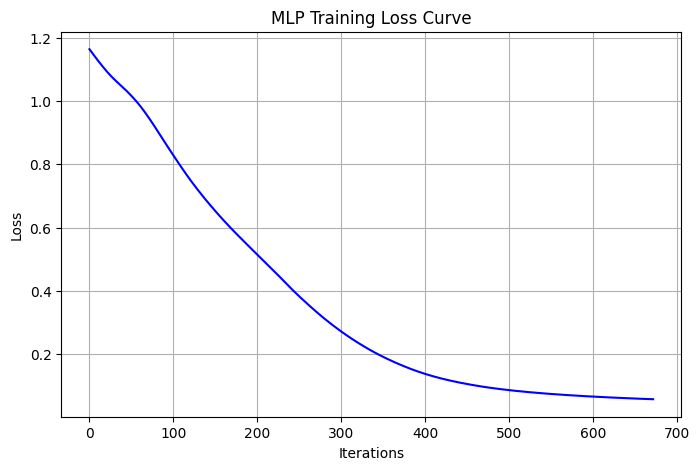

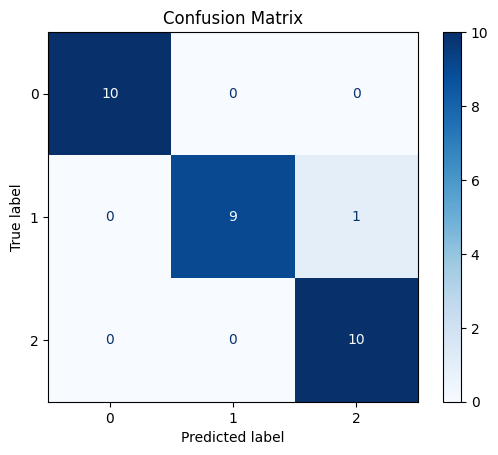

In [25]:
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# --------------------------------------------------
# Load Iris dataset
iris = datasets.load_iris()

# Features and labels
X = iris.data
y = iris.target

# --------------------------------------------------
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Feature scaling (important for MLP)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# Create MLP model
mlp_model = MLPClassifier(
    hidden_layer_sizes = (10, 5),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)
# --------------------------------------------------
# Train model
mlp_model.fit(X_train_scaled, y_train)

# --------------------------------------------------
# Predictions
y_pred = mlp_model.predict(X_test_scaled)

# --------------------------------------------------
# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --------------------------------------------------
# Loss Curve
plt.figure(figsize=(8,5))

plt.plot(mlp_model.loss_curve_, color='blue')

plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

# --------------------------------------------------
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    mlp_model,
    X_test_scaled,
    y_test,
    cmap='Blues'
)
# ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

plt.title("Confusion Matrix")
plt.show()



## MLP With Different Activations

In [34]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different activation functions
activations = ['identity', 'logistic', 'tanh', 'relu']

for af in activations:
    print(f"Training with activation: {af}")
    
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation=af,
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    
    mlp_model.fit(X_train, y_train)
    y_pred = mlp_model.predict(X_test)

    print(f"Accuracy with {af}: {accuracy_score(y_test, y_pred):.2f}")
    print("-----------------------------------------------")
    
train_pred = mlp_model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_pred))


Training with activation: identity
Accuracy with identity: 1.00
-----------------------------------------------
Training with activation: logistic
Accuracy with logistic: 0.98
-----------------------------------------------
Training with activation: tanh
Accuracy with tanh: 1.00
-----------------------------------------------
Training with activation: relu
Accuracy with relu: 1.00
-----------------------------------------------
Train Accuracy: 0.9714285714285714
Test Accuracy : 1.0


## MLP With Different Neurons

In [36]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Different neuron numbers
Num = [100, 50, 25, 10]

for i in Num:
    print(f"Training Number of Neuron: {i}")
    
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(i,),
        activation='tanh',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
    
    mlp_model.fit(X_train, y_train)
    y_pred = mlp_model.predict(X_test)

    print(f"Accuracy with Number of Neuron Equal to {i}: {accuracy_score(y_test, y_pred):.2f}")
    print("-----------------------------------------------")


train_pred = mlp_model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_pred))


Training Number of Neuron: 100
Accuracy with Number of Neuron Equal to 100: 1.00
-----------------------------------------------
Training Number of Neuron: 50
Accuracy with Number of Neuron Equal to 50: 0.98
-----------------------------------------------
Training Number of Neuron: 25
Accuracy with Number of Neuron Equal to 25: 1.00
-----------------------------------------------
Training Number of Neuron: 10
Accuracy with Number of Neuron Equal to 10: 1.00
-----------------------------------------------
Train Accuracy: 0.9714285714285714
Test Accuracy : 1.0


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


**Recognizing HandWritten Digits**


Iteration 1, loss = 2.33692439
Iteration 2, loss = 2.17167251
Iteration 3, loss = 2.00361183
Iteration 4, loss = 1.79296209
Iteration 5, loss = 1.55856653
Iteration 6, loss = 1.33077122
Iteration 7, loss = 1.12382277
Iteration 8, loss = 0.94608803
Iteration 9, loss = 0.80033825
Iteration 10, loss = 0.68171930
Iteration 11, loss = 0.58497434
Iteration 12, loss = 0.50777118
Iteration 13, loss = 0.44577261
Iteration 14, loss = 0.39444637
Iteration 15, loss = 0.35250742
Iteration 16, loss = 0.31770768
Iteration 17, loss = 0.28936756
Iteration 18, loss = 0.26543963
Iteration 19, loss = 0.24541307
Iteration 20, loss = 0.22789331
Iteration 21, loss = 0.21294992
Iteration 22, loss = 0.19966766
Iteration 23, loss = 0.18807045
Iteration 24, loss = 0.17793209
Iteration 25, loss = 0.16857443
Iteration 26, loss = 0.16040330
Iteration 27, loss = 0.15301579
Iteration 28, loss = 0.14611351
Iteration 29, loss = 0.13987900
Iteration 30, loss = 0.13434644
Iteration 31, loss = 0.12890528
Iteration 32, los

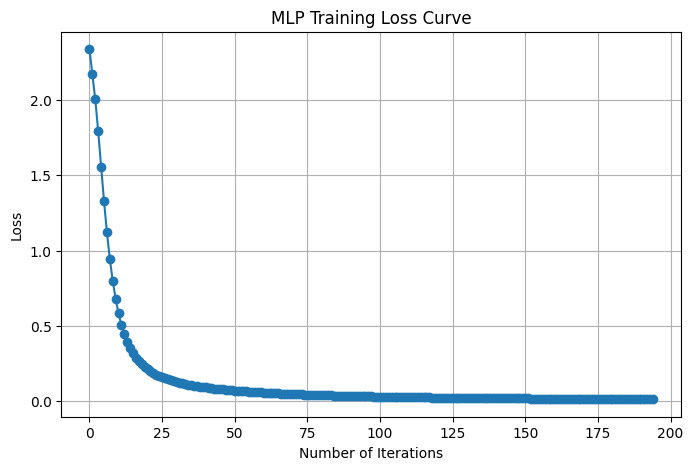

Accuracy: 0.93


In [40]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------
# Load dataset
digits = datasets.load_digits()

y = digits.target
x = digits.images.reshape((len(digits.images), -1))

# -------------------------------------------------------
# Train/Test split
x_train = x[:1000]
y_train = y[:1000]

x_test = x[1000:]
y_test = y[1000:]

# -------------------------------------------------------
# Feature Scaling
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# -------------------------------------------------------
# Create MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(15,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=500,
    random_state=42,
    verbose=True
)

# -------------------------------------------------------
# Train model
mlp.fit(x_train, y_train)

# -------------------------------------------------------
# Plot loss curve
plt.figure(figsize=(8,5))

plt.plot(mlp.loss_curve_, marker='o')

plt.xlabel("Number of Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")

plt.grid(True)
plt.show()

# -------------------------------------------------------
# Prediction
predictions = mlp.predict(x_test)

# -------------------------------------------------------
# Accuracy
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.2f}")
